### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
Long-name, ik, but let's look at how it's implemented using sklearn

In [ ]:
# Make necessary imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn libraries for datasets
from sklearn.datasets import make_moons
from sklearn.datasets import make_moons
from sklearn.datasets import make_blobs
from sklearn.datasets import make_circles

# Sklearn libraries for ml models
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

# Sklearn libraries for metrics
from sklearn.metrics import silhouette_score


### Importing the dataset

In [ ]:
# Creating a dataset to make our models learn on
X, y = make_moons(
    n_samples=1000,
    noise=0.10,
    random_state=42
    )

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 samples:\n", X[:5])

X shape: (1000, 2)
y shape: (1000,)
First 5 samples:
 [[-0.05146968  0.44419863]
 [ 1.03201691 -0.41974116]
 [ 0.86789186 -0.25482711]
 [ 0.288851   -0.44866862]
 [-0.83343911  0.53505665]]


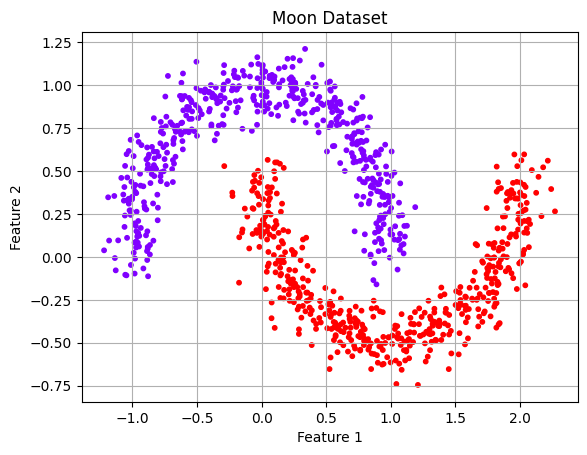

In [ ]:
# Visualize the dataset to get a better feel for it
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="rainbow", s = 10)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moon Dataset")
plt.grid(True)
plt.show()



### Instantiating the Models(SciKit)
Scikit-learn provides a very simple API for building, training and evaluating ML models, let's see how to use it

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

# We will wrap the model instantiation and plotting in a single function
def interactive_dbscan(epsilon, min_samples):
    # Fit the DBSCAN model
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples, metric="euclidean")
    labels = dbscan.fit_predict(X)

    # Plotting
    plt.figure(figsize=(10, 6), dpi=100)

    # Scatter points. Noise points are labeled as -1, which we'll make stand out.
    scatter = plt.scatter(
        X[:, 0], X[:, 1],
        c=labels, cmap="plasma",
        s=40, edgecolors="k", linewidths=0.5, alpha=0.8
    )

    plt.title(f"Interactive DBSCAN: eps={epsilon:.2f}, min_samples={min_samples}", fontsize=14, fontweight="bold")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

# Generate the interactive sliders
interact(
    interactive_dbscan,
    epsilon=widgets.FloatSlider(value=0.1, min=0.01, max=0.3, step=0.01, description='Epsilon:'),
    min_samples=widgets.IntSlider(value=5, min=1, max=20, step=1, description='Min Samples:')
)

interactive(children=(FloatSlider(value=0.1, description='Epsilon:', max=0.3, min=0.01, step=0.01), IntSlider(…

<function __main__.interactive_dbscan(epsilon, min_samples)>

### DIY DBSCAN: Building it from Scratch
Instead of using a black box, let's write it ourselves! Think of DBSCAN as a graph algorithm. Two points have an "edge" between them if their distance is $\le \epsilon$.

Our first step is to write a helper function that acts as our "radar" to find all neighbors within that $\epsilon$ radius. Fill in the blanks (`_____`).

In [ ]:
def get_neighbors(data, point_idx, epsilon):
    """
    Finds all points within `epsilon` distance from `data[point_idx]`.
    """
    neighbors = []

    for i in range(len(data)):
        # TODO 1: Calculate the Euclidean distance between data[point_idx] and data[i]
        # HINT: np.linalg.norm() calculates the magnitude of a vector
        distance = np.linalg.norm(data[point_idx] - data[i])

        # TODO 2: If the distance is less than or equal to epsilon, it's a neighbor!
        if distance <= epsilon:
            neighbors.append(i)

    return neighbors

### The Main Algorithm
Here is the skeleton of DBSCAN.
We will use an array `labels` to track state:
* `0` = Unvisited
* `-1` = Noise
* `1, 2, 3...` = Valid Cluster IDs

Your job is to implement the core point checks and the BFS (Breadth-First Search) queue expansion.

In [ ]:
def custom_dbscan(data, epsilon, min_samples):
    labels = np.zeros(len(data), dtype=int) # Start with all 0s (Unvisited)
    cluster_id = 0

    for p in range(len(data)):
        # Skip if we've already visited this point
        if labels[p] != 0:
            continue

        # Get neighbors using our helper function
        neighbors = get_neighbors(data, p, epsilon)

        # TODO 3: Check if the current point is a CORE point
        if len(neighbors) < min_samples:
            # Not enough neighbors? Label it as noise for now.
            labels[p] = -1
        else:
            # We found a core point! Start a new cluster.
            cluster_id += 1
            labels[p] = cluster_id

            # --- BFS Queue Expansion ---
            # We use a while loop because 'neighbors' will grow as we find more points
            i = 0
            while i < len(neighbors):
                neighbor_idx = neighbors[i]

                # TODO 4: If this neighbor was previously labeled NOISE, claim it for our current cluster
                if labels[neighbor_idx] == -1:
                    labels[neighbor_idx] = cluster_id

                # TODO 5: If this neighbor is completely UNVISITED, process it
                elif labels[neighbor_idx] == 0:
                    # Assign it to the current cluster
                    labels[neighbor_idx] = cluster_id

                    # Check if THIS neighbor is ALSO a core point
                    new_neighbors = get_neighbors(data, neighbor_idx, epsilon)

                    # TODO 6: If it has enough neighbors, add them to our BFS queue to keep expanding!
                    if len(new_neighbors) >= min_samples:
                        neighbors.extend(new_neighbors)

                i += 1 # Move to the next item in the queue

    return labels

### Hyperparameter tuning
Hyperparameters are parameters preset by data scientists(like us) to define any configurable part of a learning process </br>

There are no rules on how to set them, tuning depends largely on observing model performance on our training data.


In [ ]:
# Tune the following hyperparameters

# Hyperparameters for DBSCAN
EPSILON = 0.13
MIN_SAMPLES = 5

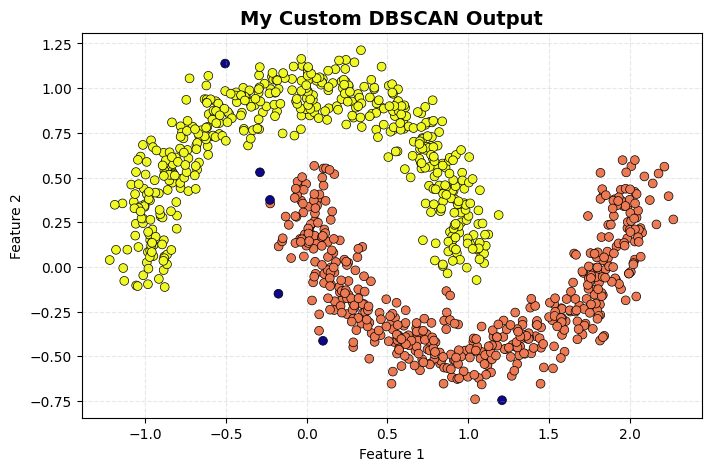

In [ ]:
# Let's test your implementation!
# (Ensure your Epsilon and min_samples match the ones we tuned earlier)
my_labels = custom_dbscan(X, epsilon=EPSILON, min_samples=MIN_SAMPLES)

plt.figure(figsize=(8, 5))
plt.scatter(
    X[:, 0], X[:, 1],
    c=my_labels, cmap="plasma",
    s=40, edgecolors="k", linewidths=0.5
)
plt.title("My Custom DBSCAN Output", fontsize=14, fontweight="bold")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

### Plotting
Let's visually analyse how well each of the models performed

### Metrics to evaluate performance
In unsupervised Learning, there are no labels so we can't evaluate the performance intuitively using stuff like accuracy, instead we use a wide variety of metrics </br>

A popular metric to use is `silhouette_score` it is computed as


### Step 1: Compute a(i)

Average distance between point *i* and all other points in the same cluster.

$$
a(i) = \frac{1}{|C_i|-1} \sum_{j \in C_i, j \ne i} d(i, j)
$$

where $C_i$ is the cluster of point *i*.

---

### Step 2: Compute b(i)

Minimum average distance between point *i* and all points in the nearest different cluster.

$$
b(i) = \min_{k \ne C_i} \frac{1}{|C_k|} \sum_{j \in C_k} d(i, j)
$$

where $C_k$ represents another cluster.

---

### Step 3: Compute Silhouette Value s(i)

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

---

### Step 4: Overall Silhouette Score

The final silhouette score is the average over all points:

$$
S = \frac{1}{n} \sum_{i=1}^{n} s(i)
$$




In [ ]:
my_labels = custom_dbscan(X, epsilon=0.13, min_samples=5)

# 2. Check how many unique clusters your code actually found
unique_labels = np.unique(my_labels)
print(f"Clusters found by your DIY algorithm (Note: -1 is noise): {unique_labels}")

# 3. Calculate the Silhouette Score safely
if len(unique_labels) > 1:
    diy_score = silhouette_score(X, my_labels)
    print(f"🏆 Your DIY DBSCAN Silhouette Score: {diy_score:.4f}")

else:
    print("Oops! Your DIY algorithm only found 1 cluster (or just noise).")
    print("Silhouette score requires at least 2 clusters to calculate.")
    print("Check your BFS queue expansion logic!")

Clusters found by your DIY algorithm (Note: -1 is noise): [-1  1  2]
🏆 Your DIY DBSCAN Silhouette Score: 0.1674


Note: Higher magnitude of silhouette score is usually better

Repeat on another popular dataset

X shape: (1000, 2)
y shape: (1000,)
First 5 samples:
 [[ 0.54913055  0.19451746]
 [-0.53669511  0.13616421]
 [-0.63143577  0.19689234]
 [-0.34397973  0.49126478]
 [ 0.44560223 -0.89493556]]


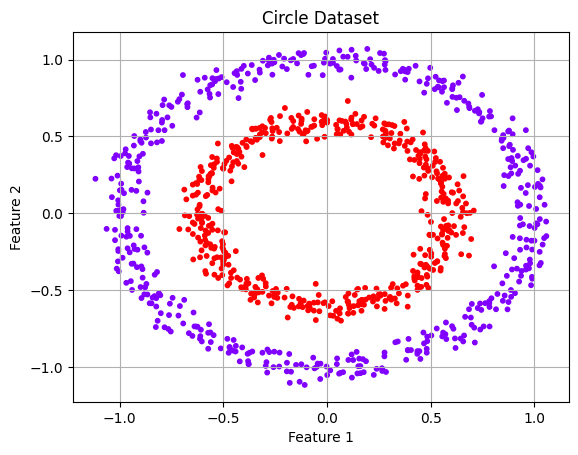

In [ ]:
#repeating on another
X2, y2 = make_circles(
    n_samples=1000,
    noise=0.05, #reduced noise a bit
    factor = 0.6, #gave them a gap
    random_state=42
    )

print("X shape:", X2.shape)
print("y shape:", y2.shape)
print("First 5 samples:\n", X2[:5])

#visualising
plt.scatter(X2[:, 0], X2[:, 1], c=y2, cmap="rainbow", s = 10)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Circle Dataset")
plt.grid(True)
plt.show()

In [ ]:
#to visualise
def interactive_dbscan(epsilon, min_samples):
    # Fit the DBSCAN model
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples, metric="euclidean")
    labels = dbscan.fit_predict(X2)

    # Plotting
    plt.figure(figsize=(10, 6), dpi=100)

    # Scatter points. Noise points are labeled as -1, which we'll make stand out.
    scatter = plt.scatter(
        X2[:, 0], X2[:, 1],
        c=labels, cmap="plasma",
        s=40, edgecolors="k", linewidths=0.5, alpha=0.8
    )

    plt.title(f"Interactive DBSCAN: eps={epsilon:.2f}, min_samples={min_samples}", fontsize=14, fontweight="bold")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

# Generate the interactive sliders
interact(
    interactive_dbscan,
    epsilon=widgets.FloatSlider(value=0.1, min=0.01, max=0.3, step=0.01, description='Epsilon:'),
    min_samples=widgets.IntSlider(value=5, min=1, max=20, step=1, description='Min Samples:')
)

interactive(children=(FloatSlider(value=0.1, description='Epsilon:', max=0.3, min=0.01, step=0.01), IntSlider(…

<function __main__.interactive_dbscan(epsilon, min_samples)>

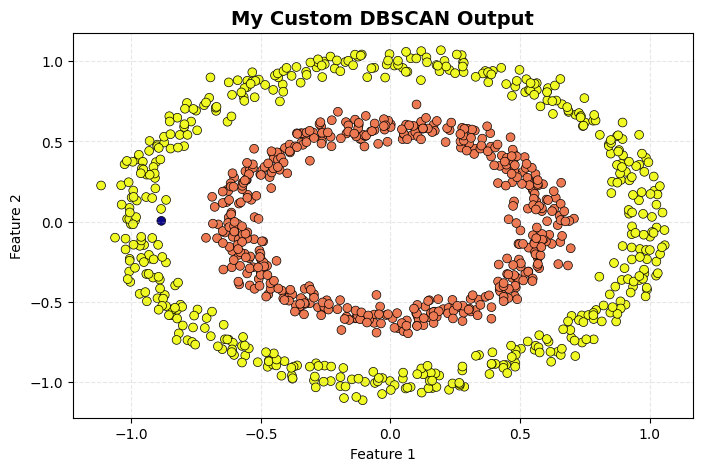

In [ ]:
my_labels = custom_dbscan(X2, epsilon=0.10, min_samples=6)

plt.figure(figsize=(8, 5))
plt.scatter(
    X2[:, 0], X2[:, 1],
    c=my_labels, cmap="plasma",
    s=40, edgecolors="k", linewidths=0.5
)
plt.title("My Custom DBSCAN Output", fontsize=14, fontweight="bold")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()



In [ ]:
my_labels = custom_dbscan(X2, epsilon=0.10, min_samples=6)

# 2. Check how many unique clusters your code actually found
unique_labels = np.unique(my_labels)
print(f"Clusters found by your DIY algorithm (Note: -1 is noise): {unique_labels}")

# 3. Calculate the Silhouette Score safely
if len(unique_labels) > 1:
    diy_score = silhouette_score(X2, my_labels)
    print(f"🏆 Your DIY DBSCAN Silhouette Score: {diy_score:.4f}")

else:
    print("Oops! Your DIY algorithm only found 1 cluster (or just noise).")
    print("Silhouette score requires at least 2 clusters to calculate.")
    print("Check your BFS queue expansion logic!")

Clusters found by your DIY algorithm (Note: -1 is noise): [-1  1  2]
🏆 Your DIY DBSCAN Silhouette Score: -0.1238
